In [2]:
import numpy as np
from hmmlearn.hmm import MultinomialHMM

startprob = np.array([0.5, 0.5])  # Initial state probabilities
transition_matrix = np.array([
    [0.7, 0.3],  # Sunny
    [0.3, 0.7],  # Rainy
])

covariance_matrix = np.array([ # Covariance matrix for the states
    [0.9, 0.1],  # Sunny
    [0.2, 0.8],  # Rainy
])



model = MultinomialHMM(n_components=2, startprob_prior = startprob, transmat_prior = transition_matrix, n_iter=1000)
# n_components is the number of states
# n_init is the number of iterations for training

X = [[0,0,1,0],[0,0,0,0],[1,1,1,0],[0,0,1,0]]  # Observed sequence (0 for Umbrella, 1 for No Umbrella)
model.fit(X)

print(model.transmat_)  # Transition matrix
# Fit the model to the observed data

MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
C:\Users\leshi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\hmmlearn\hmm.py:942: RuntimeWarning: invalid value encountered in divide
  stats['obs'] / stats['obs'].sum(axis=1, keepdims=True))
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero s

[[ 0.  0.]
 [nan nan]]


In [1]:
import numpy as np
from hmmlearn import hmm

# Define the number of states
states = ["Sunny", "Cloudy", "Rainy"]
n_states = len(states)

# Define the possible observations
observations = ["Umbrella", "No Umbrella"]
n_observations = len(observations)

# Initialize the HMM model
model = hmm.MultinomialHMM(n_components=n_states, n_iter=1000)


# Transition probability matrix
transition_matrix = np.array([
    [0.7, 0.2, 0.1],  # Sunny
    [0.3, 0.4, 0.3],  # Cloudy
    [0.3, 0.3, 0.4]   # Rainy
])

# Emission probability matrix
emission_matrix = np.array([
    [0.1, 0.9],  
    [0.4, 0.6],  
    [0.7, 0.3]   
])

model.startprob_ = np.array([0.6, 0.3, 0.1])  # Initial state probabilities
model.transmat_ = transition_matrix
model.emissionprob_ = emission_matrix


# Observed sequence (0 for Umbrella, 1 for No Umbrella)
observed_sequence = np.array([[0, 1, 0, 0, 1]]).T

# Train the model
model.fit(observed_sequence)

print(model.transmat_)

log_likelihood = model.score(observed_sequence)
print(f"Log-Likelihood: {log_likelihood}")


predicted_states = model.predict(observed_sequence)
print(f"Predicted states: {predicted_states}")

MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Fitting a model with 8 free scalar parameters with only 5 data points will result in a degenerate solution.


[[4.18874032e-03 9.57163381e-01 3.86478787e-02]
 [3.19224904e-01 6.49187527e-01 3.15875690e-02]
 [1.24273663e-04 1.49730047e-01 8.50145679e-01]]
Log-Likelihood: -2.7755575615628914e-16
Predicted states: [1 1 1 1 1]


O1    0.25
O2    0.40
O3    0.35
Name: states, dtype: float64
1.0
      O1    O2   O3
O1   0.4   0.2  0.4
O2  0.45  0.45  0.1
O3  0.45  0.25  0.3


[[0.4 0.2 0.4]
 [0.45 0.45 0.1]
 [0.45 0.25 0.3]] (3, 3)


O1    1.0
O2    1.0
O3    1.0
dtype: object
{('O1', 'O1'): 0.4,
 ('O1', 'O2'): 0.2,
 ('O1', 'O3'): 0.4,
 ('O2', 'O1'): 0.45,
 ('O2', 'O2'): 0.45,
 ('O2', 'O3'): 0.1,
 ('O3', 'O1'): 0.45,
 ('O3', 'O2'): 0.25,
 ('O3', 'O3'): 0.3}
Nodes:

['O1', 'O2', 'O3']


Edges:
OutMultiEdgeDataView([('O1', 'O1', {'weight': 0.4, 'label': 0.4}), ('O1', 'O2', {'weight': 0.2, 'label': 0.2}), ('O1', 'O3', {'weight': 0.4, 'label': 0.4}), ('O2', 'O1', {'weight': 0.45, 'label': 0.45}), ('O2', 'O2', {'weight': 0.45, 'label': 0.45}), ('O2', 'O3', {'weight': 0.1, 'label': 0.1}), ('O3', 'O1', {'weight': 0.45, 'label': 0.45}), ('O3', 'O2', {'weight': 0.25, 'label': 0.25}), ('O3', 'O3', {'weight': 0.3, 'label': 0.3})])


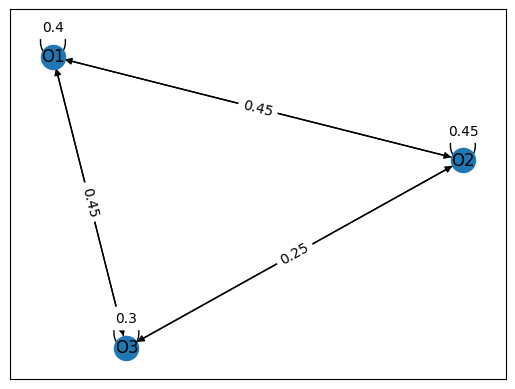



S1    0.5
S2    0.5
Name: states, dtype: float64


1.0
     S1   S2
S1  0.7  0.3
S2  0.4  0.6


[[0.7 0.3]
 [0.4 0.6]]
(2, 2)


S1    1.0
S2    1.0
dtype: object
     O1   O2   O3
S1  0.2  0.6  0.2
S2  0.4  0.1  0.5


[[0.2 0.6 0.2]
 [0.4 0.1 0.5]]
(2, 3)


S1    1.0
S2    1.0
dtype: object
{('S1', 'S1'): 0.7, ('S1', 'S2'): 0.3, ('S2', 'S1'): 0.4, ('S2', 'S2'): 0.6}
{('S1', 'O1'): 0.2,
 ('S1', 'O2'): 0.6,
 ('S1', 'O3'): 0.2,
 ('S2', 'O1'): 0.4,
 ('S2', 'O2'): 0.1,
 ('S2', 'O3'): 0.5}
Nodes:

['S1', 'S2']


Edges:
OutMultiEdgeDataView([('S1', 'S1', {'weight': 0.7, 'label': 0.7}), ('S1', 'S2', {'weight': 0.3, 'label': 0.3}), ('S1', 'O1', {'weight': 0.2, 'label': 0.2}), ('S1', 'O2', {'weight': 0.6, 'label': 0.6}), ('S1', 'O3', {'weight': 0.2, 'label': 0.2}), ('S2', 'S1', {'weight': 0.4, 'label': 0.4}), ('S2', 'S2', {'weight': 0.6, 'label': 0.6}), ('S2', 'O1', {'weight': 0.4, 'label': 0.4}), ('S2', 'O2', {'weight': 0.1, 'label': 0.1}), ('S2', 'O3', {'weight': 0.5, 'label': 0.5})])


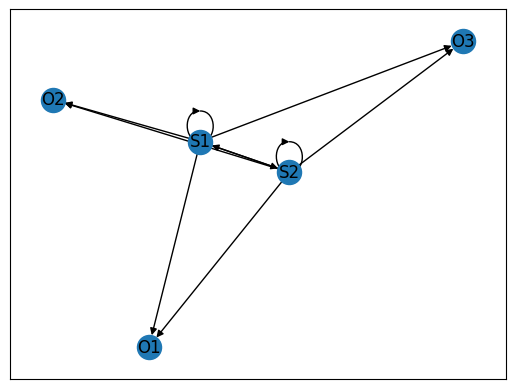

   Obs_code Obs_seq
0         1      O2
1         1      O2
2         2      O3
3         1      O2
4         0      O1
5         1      O2
6         2      O3
7         1      O2
8         0      O1
9         2      O3
10        2      O3
11        0      O1
12        1      O2
13        0      O1
14        1      O2


single best state path:  [0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0.]
delta:
 [[3.00000000e-01 1.26000000e-01 1.76400000e-02 7.40880000e-03
  1.03723200e-03 4.35637440e-04 6.09892416e-05 2.56154815e-05
  3.58616741e-06 5.02063437e-07 7.37725866e-08 2.21317760e-08
  1.59348787e-08 2.23088302e-09 9.36970868e-10]
 [5.00000000e-02 9.00000000e-03 1.89000000e-02 1.13400000e-03
  8.89056000e-04 5.33433600e-05 6.53456160e-05 3.92073696e-06
  3.07385778e-06 9.22157333e-07 2.76647200e-07 6.63953280e-08
  3.98371968e-09 1.91218545e-09 1.14731127e-10]]
phi:
 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0.]
 [0. 0. 0. 1. 0. 1. 0. 1. 0. 1. 1. 1. 1. 0. 1.]]
   Observation Best_Path
0

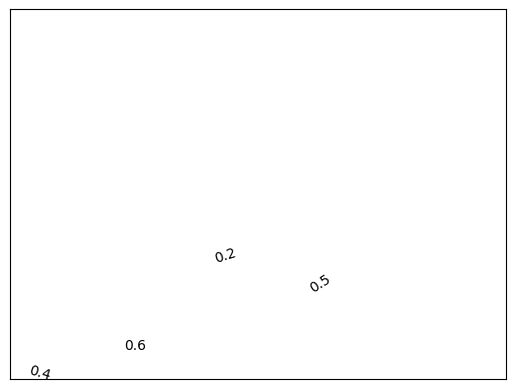

In [9]:
import numpy as np
import pandas as pd
import networkx.drawing.nx_pydot as gl
import networkx as nx
import matplotlib.pyplot as plt
from pprint import pprint
##matplotlib inline

# create state space and initial state probabilities

states = ['O1', 'O2', 'O3']
pi = [0.25, 0.4, 0.35]
state_space = pd.Series(pi, index=states, name='states')
print(state_space)
print(state_space.sum())

# create transition matrix
# equals transition probability matrix of changing states given a state
# matrix is size (M x M) where M is number of states

q_df = pd.DataFrame(columns=states, index=states)
q_df.loc[states[0]] = [0.4, 0.2, 0.4]
q_df.loc[states[1]] = [0.45, 0.45, 0.1]
q_df.loc[states[2]] = [0.45, 0.25, .3]

print(q_df)

q = q_df.values
print('\n')
print(q, q.shape)
print('\n')
print(q_df.sum(axis=1))

from pprint import pprint 

# create a function that maps transition probability dataframe 
# to markov edges and weights

def _get_markov_edges(Q):
    edges = {}
    for col in Q.columns:
        for idx in Q.index:
            edges[(idx,col)] = Q.loc[idx,col]
    return edges

edges_wts = _get_markov_edges(q_df)
pprint(edges_wts)

# create graph object
G = nx.MultiDiGraph()

# nodes correspond to states
G.add_nodes_from(states)
print('Nodes:\n')
print(G.nodes())
print('\n')

# edges represent transition probabilities
for k, v in edges_wts.items():
    tmp_origin, tmp_destination = k[0], k[1]
    G.add_edge(tmp_origin, tmp_destination, weight=v, label=v)
print('Edges:')
pprint(G.edges(data=True))

# Use spring_layout to avoid requiring Graphviz/dot
pos = nx.spring_layout(G)
nx.draw_networkx(G, pos)

# create edge labels for jupyter plot but is not necessary
edge_labels = {(n1,n2):d['label'] for n1,n2,d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G , pos, edge_labels=edge_labels)
nx.drawing.nx_pydot.write_dot(G, 'markov.dot')
plt.show()

# create state space and initial state probabilities

hidden_states = ['S1', 'S2']
pi = [0.5, 0.5]
print('\n')
state_space = pd.Series(pi, index=hidden_states, name='states')
print(state_space)
print('\n')
print(state_space.sum())

# create hidden transition matrix
# a or alpha 
#   = transition probability matrix of changing states given a state
# matrix is size (M x M) where M is number of states

a_df = pd.DataFrame(columns=hidden_states, index=hidden_states)
a_df.loc[hidden_states[0]] = [0.7, 0.3]
a_df.loc[hidden_states[1]] = [0.4, 0.6]

print(a_df)

a = a_df.values
print('\n')
print(a)
print(a.shape)
print('\n')
print(a_df.sum(axis=1))

# create matrix of observation (emission) probabilities
# b or beta = observation probabilities given state
# matrix is size (M x O) where M is number of states 
# and O is number of different possible observations

observable_states = states

b_df = pd.DataFrame(columns=observable_states, index=hidden_states)
b_df.loc[hidden_states[0]] = [0.2, 0.6, 0.2]
b_df.loc[hidden_states[1]] = [0.4, 0.1, 0.5]

print(b_df)

b = b_df.values
print('\n')
print(b)
print(b.shape)
print('\n')
print(b_df.sum(axis=1))

# create graph edges and weights

hide_edges_wts = _get_markov_edges(a_df)
pprint(hide_edges_wts)

emit_edges_wts = _get_markov_edges(b_df)
pprint(emit_edges_wts)

# create graph object
G = nx.MultiDiGraph()

# nodes correspond to states
G.add_nodes_from(hidden_states)
print('Nodes:\n')
print(G.nodes())
print('\n')

# edges represent hidden probabilities
for k, v in hide_edges_wts.items():
    tmp_origin, tmp_destination = k[0], k[1]
    G.add_edge(tmp_origin, tmp_destination, weight=v, label=v)

# edges represent emission probabilities
for k, v in emit_edges_wts.items():
    tmp_origin, tmp_destination = k[0], k[1]
    G.add_edge(tmp_origin, tmp_destination, weight=v, label=v)
    
print('Edges:')
pprint(G.edges(data=True))    
# Use spring_layout to avoid requiring Graphviz/dot
pos = nx.spring_layout(G)
nx.draw_networkx(G, pos)
plt.show()
plt.show()

# create edge labels 
emit_edge_labels = {(n1,n2):d['label'] for n1,n2,d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G , pos, edge_labels=emit_edge_labels)
#plt.show()
nx.drawing.nx_pydot.write_dot(G, 'hidden_markov.dot')

# observation sequence of dog's behaviors
# observations are encoded numerically

obs_map = {'O1':0, 'O2':1, 'O3':2}
obs = np.array([1,1,2,1,0,1,2,1,0,2,2,0,1,0,1])

inv_obs_map = dict((v,k) for k, v in obs_map.items())
obs_seq = [inv_obs_map[v] for v in list(obs)]

print( pd.DataFrame(np.column_stack([obs, obs_seq]), 
                columns=['Obs_code', 'Obs_seq']) )

def viterbi(pi,a,b,obs):

	nStates = np.shape(b)[0]
	T = np.shape(obs)[0]

	path = np.zeros(T)
	delta = np.zeros((nStates,T))
	phi = np.zeros((nStates,T))

	delta[:,0] = pi * b[:,obs[0]]
	phi[:,0] = 0

	for t in range(1,T):
		for s in range(nStates):
			delta[s,t] = np.max(delta[:,t-1]*a[:,s])*b[s,obs[t]]
			phi[s,t] = np.argmax(delta[:,t-1]*a[:,s])

	path[T-1] = np.argmax(delta[:,T-1])
	for t in range(T-2,-1,-1):
		#path[t] = phi[int(path[t+1]): int(t+1) , int(t+1)]
		path[t] = phi[int(path[t+1]) , int(t+1)]

	return path,delta, phi

path, delta, phi = viterbi(pi, a, b, obs)
print('\n')
print('single best state path: ', path)
print('delta:\n', delta)
print('phi:\n', phi)

state_map = {0:'S1', 1:'S2'}
state_path = [state_map[v] for v in path]


result = (pd.DataFrame()
 .assign(Observation=obs_seq)
 .assign(Best_Path=state_path))
 
print(result)

Respuestas del usuario:
['Alta', 'Neutra', 'Neutra', 'Baja', 'Alta', 'Neutra']

Estados emocionales estimados:
['Indiferente', 'Indiferente', 'Indiferente', 'Indiferente', 'Neutro', 'Neutro']


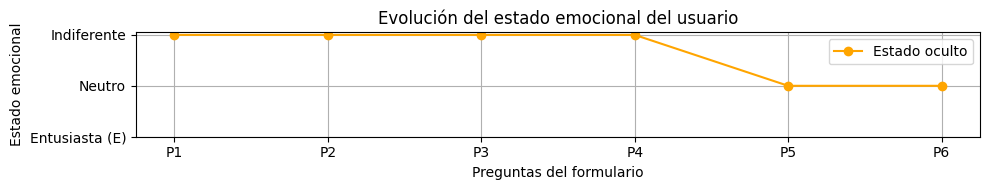

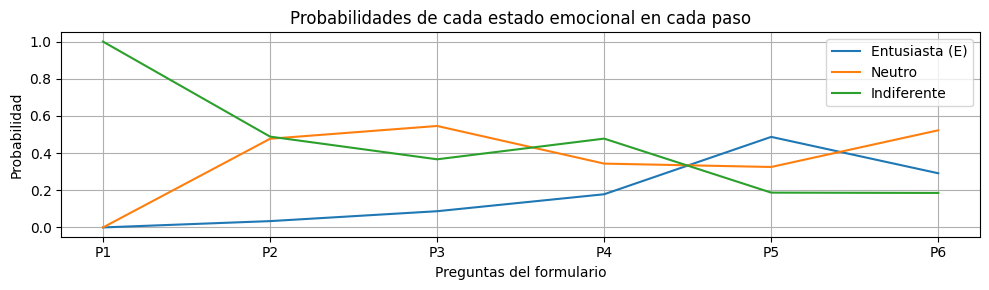

In [ ]:
import numpy as np
from hmmlearn.hmm import CategoricalHMM
import matplotlib.pyplot as plt

# Paso 1: Definir el modelo HMM
modelo = CategoricalHMM(n_components=3, n_iter=1000)

# Paso 2: Etiquetas para entender los estados
estados_ocultos = ['Entusiasta (E)', 'Neutro', 'Indiferente']
observaciones = ['Baja', 'Neutra', 'Alta']                                                       # N° de Coherencia

# Paso 3: Configurar parámetros del modelo

# Matriz de inicio: probabilidad de comenzar en cada estado
modelo.startprob_ = np.array([0/3, 0/3, 3/3])                   # Distribución Inicial es dada por la media estadística de la P21

# Matriz de transición entre estados
modelo.transmat_ = np.array([
    [0.7, 0.2, 0.1],
    [0.3, 0.5, 0.2],
    [0.1, 0.3, 0.6],
])

# Matriz de emisión: probabilidad de dar una respuesta observable desde cada estado oculto
# Filas = estados ocultos, Columnas = observaciones (0=Negativa, 1=Neutral, 2=Positiva)
modelo.emissionprob_ = np.array([
    [0.1, 0.2, 0.7],  # Entusiasta
    [0.2, 0.6, 0.2],  # Neutro
    [0.6, 0.3, 0.1],  # Escéptico
])

# Paso 4: Secuencia de respuestas del usuario (6 preguntas)
# 2 = Positiva, 1 = Neutral, 0 = Negativa
respuestas_usuario = np.array([[2], [1], [1], [0], [2], [1]])

# Paso 5: Calcular la secuencia más probable de estados (Viterbi)
log_prob, secuencia_estados = modelo.decode(respuestas_usuario, algorithm="viterbi")

# Paso 6: Mostrar resultados
print("Respuestas del usuario:")
print([observaciones[o[0]] for o in respuestas_usuario])

print("\nEstados emocionales estimados:")
print([estados_ocultos[s] for s in secuencia_estados])

# Visualización
plt.figure(figsize=(10, 2))
plt.plot(secuencia_estados, marker='o', color='orange', label="Estado oculto")
plt.yticks([0, 1, 2], estados_ocultos)
plt.xticks(range(len(respuestas_usuario)), [f"P{i+1}" for i in range(len(respuestas_usuario))])
plt.title("Evolución del estado emocional del usuario")
plt.xlabel("Preguntas del formulario")
plt.ylabel("Estado emocional")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



# Paso intermedio para obtener gamma (probabilidad posterior de cada estado por paso)
gamma = modelo.predict_proba(respuestas_usuario)

# Graficar evolución completa de gamma
plt.figure(figsize=(10, 3))
for i in range(3):
    plt.plot(gamma[:, i], label=estados_ocultos[i])
plt.title("Probabilidades de cada estado emocional en cada paso")
plt.xlabel("Preguntas del formulario")
plt.ylabel("Probabilidad")
plt.xticks(range(len(respuestas_usuario)), [f"P{i+1}" for i in range(len(respuestas_usuario))])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()